In [315]:
# =========================
# IMPORTS GENERALES
# =========================

# pandas y numpy se usan para trabajar con datos tabulares
# y realizar operaciones numéricas de forma eficiente.
import pandas as pd
import numpy as np

# matplotlib y seaborn se utilizan para generar gráficas
# que nos ayuden a entender mejor el comportamiento de los datos.
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn para dividir datos,
# entrenar árboles de decisión y evaluar resultados.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# warnings se usa para ocultar avisos que no afectan
# al funcionamiento del notebook y así mantenerlo más limpio.
import warnings
warnings.filterwarnings("ignore")

# Ajustes visuales de pandas para mostrar más columnas y filas
# cuando inspeccionamos los datasets.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Configuración estética general de seaborn para que
# las gráficas tengan un formato más profesional.
sns.set_theme(style="whitegrid")

"""
PoC - Detección de anomalías de comportamiento en Login Log y Activity Log
=========================================================================

Objetivo:
---------
Construir un sistema de Machine Learning basado en Árboles de Decisión que sea capaz de detectar
comportamientos anómalos en el uso de una aplicación tipo gestor de contraseñas.

Reglas de negocio definidas:
----------------------------
1. Login Log:
   - Los usuarios trabajan de lunes a viernes entre las 09:00 y las 18:00.
   - Usuario 1 (Matteo Nicolosi): logins habituales entre 09:00 y 12:00.
   - Usuario 2 (Diego Scardino): logins habituales entre 12:00 y 15:00.
   - Usuario 3 (Emilio Sardo): logins habituales entre 15:00 y 18:00.

2. Activity Log:
   - Las acciones válidas se realizan de lunes a viernes entre las 09:00 y las 18:00.
   - Solo se consideran normales acciones sobre entity_id = 1 (password)
     dentro de los elementos asignados a cada usuario.
   - Acciones disponibles:
       1000000 -> Visualize
       1000001 -> Create
       1000002 -> Edit
       1000003 -> Delete
       1000004 -> Copy
       1000005 -> Share

3. Objetivos del modelo:
   - Detectar logins fuera de la franja habitual del usuario.
   - Detectar acciones sobre elementos no autorizados para ese usuario.
   - Detectar acciones fuera del horario laboral o en días no laborables.
"""

In [316]:
# =========================
# CARGA DE DATOS
# =========================

# Rutas de los archivos CSV.
# Si tus ficheros tienen otro nombre o están en otra carpeta,
# aquí es donde debes cambiarlo.
login_path = 'login_log_202604091116.csv'
activity_path = 'activity_log_202604091116.csv'

# Leemos ambos archivos con pandas.
# Cada CSV se convierte en un DataFrame.
keyoverLogin = pd.read_csv(login_path)
keyoverActivity = pd.read_csv(activity_path)

# Mostramos el tamaño de cada dataset para comprobar
# que se han cargado correctamente.
print("Dimensiones Login Log:", keyoverLogin.shape)
print("Dimensiones Activity Log:", keyoverActivity.shape)

Dimensiones Login Log: (1318, 6)
Dimensiones Activity Log: (3000, 6)


In [317]:
# Mostramos una vista previa de los datos para entender
# cómo están estructurados los registros de login.
print("LOGIN LOG")
display(keyoverLogin.head())

# Mostramos una vista previa del dataset de actividad
# para ver qué información contiene cada acción realizada.
print("\nACTIVITY LOG")
display(keyoverActivity.head())

LOGIN LOG


,login_log_id,user_id,result,attempt,logged_at,logout_at
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837



ACTIVITY LOG


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at
0,1,1,2,1,1000000,2026-01-01 10:31:04.217
1,2,2,3,1,1000004,2026-01-01 14:37:47.860
2,3,3,6,1,1000005,2026-01-01 17:44:36.455
3,4,1,1,1,1000000,2026-01-02 10:14:36.855
4,5,1,2,1,1000000,2026-01-02 10:15:31.904


In [318]:
# info() nos permite revisar:
# - número de filas
# - número de columnas
# - tipo de dato de cada columna
# - cuántos valores no nulos hay
# Esto ayuda a detectar problemas antes del análisis.
print("======== LOGIN LOG INFO ========")
print(keyoverLogin.info())

print("\n======== ACTIVITY LOG INFO ========")
print(keyoverActivity.info())

======== LOGIN LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   login_log_id  1318 non-null   int64
 1   user_id       1318 non-null   int64
 2   result        1318 non-null   bool 
 3   attempt       1318 non-null   int64
 4   logged_at     1318 non-null   str  
 5   logout_at     1318 non-null   str  
dtypes: bool(1), int64(3), str(2)
memory usage: 52.9 KB
None

======== ACTIVITY LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   activity_log_id  3000 non-null   int64
 1   user_id          3000 non-null   int64
 2   element_id       3000 non-null   int64
 3   entity_id        3000 non-null   int64
 4   action_id        3000 non-null   int64
 5   logged_at        3000 non-null   str  

In [319]:
# Comprobamos si hay valores nulos en el dataset de login.
# Esto es importante porque los modelos no suelen trabajar bien con nulos.
print("NULOS LOGIN LOG")
display(keyoverLogin.isnull().sum())

# Comprobamos si hay valores nulos en el dataset de actividad.
print("\nNULOS ACTIVITY LOG")
display(keyoverActivity.isnull().sum())

# También revisamos si hay filas duplicadas.
# Los duplicados pueden introducir sesgos en el entrenamiento.
print("\nDUPLICADOS LOGIN LOG:", keyoverLogin.duplicated().sum())
print("DUPLICADOS ACTIVITY LOG:", keyoverActivity.duplicated().sum())

NULOS LOGIN LOG


login_log_id    0
user_id         0
result          0
attempt         0
logged_at       0
logout_at       0
dtype: int64


NULOS ACTIVITY LOG


activity_log_id    0
user_id            0
element_id         0
entity_id          0
action_id          0
logged_at          0
dtype: int64


DUPLICADOS LOGIN LOG: 0
DUPLICADOS ACTIVITY LOG: 0


In [320]:
# =========================
# CONVERSIÓN DE FECHAS
# =========================

# Convertimos las columnas temporales de login a formato datetime.
# Esto permitirá extraer información temporal de forma sencilla.
keyoverLogin["logged_at"] = pd.to_datetime(keyoverLogin["logged_at"], errors="coerce")
keyoverLogin["logout_at"] = pd.to_datetime(keyoverLogin["logout_at"], errors="coerce")

# Hacemos lo mismo con la columna temporal del dataset de actividad.
keyoverActivity["logged_at"] = pd.to_datetime(keyoverActivity["logged_at"], errors="coerce")

# Mensaje de confirmación.
print("Conversión de fechas realizada correctamente.")

Conversión de fechas realizada correctamente.


In [321]:
# =========================
# DICCIONARIOS DE NEGOCIO
# =========================

# Relación entre user_id y nombre real del usuario.
# Esto mejora la legibilidad del análisis y las tablas finales.
user_names = {
    1: "Matteo Nicolosi",
    2: "Diego Scardino",
    3: "Emilio Sardo"
}

# Relación entre action_id y nombre descriptivo de la acción.
# También sirve para que las gráficas y resultados sean más comprensibles.
action_names = {
    1000000: "Visualize",
    1000001: "Create",
    1000002: "Edit",
    1000003: "Delete",
    1000004: "Copy",
    1000005: "Share"
}

# Ventanas horarias habituales de login por usuario.
# Estas reglas se usarán para detectar accesos fuera de lo normal.
login_windows = {
    1: (9, 12),   # Matteo
    2: (12, 15),  # Diego
    3: (15, 18)   # Emilio
}

# Elementos permitidos por usuario en el Activity Log.
# Si un usuario actúa sobre un element_id no autorizado,
# la acción se considerará anómala.
allowed_elements = {
    1: [1, 2],          # Matteo -> FVG, AMCO
    2: [3],             # Diego -> VETTING
    3: [4, 1, 5, 6]     # Emilio -> RHODENSE, FVG, PAPARDO, PULEJO
}

# Entity válida según el enunciado del PoC.
# Se asume que las acciones normales son sobre entity_id = 1 (password).
allowed_entity_id = 1

# Acciones consideradas normales en el flujo estándar descrito.
# Si negocio luego confirma más acciones como normales,
# bastará con ampliar esta lista.
allowed_actions = [1000000, 1000004, 1000005]   # Visualize, Copy, Share

print("Diccionarios cargados.")

Diccionarios cargados.


In [322]:
# =========================
# FEATURE ENGINEERING LOGIN
# =========================

# Creamos una copia para no modificar el dataset original.
login_df = keyoverLogin.copy()

# Añadimos el nombre del usuario usando el diccionario definido antes.
login_df["user_name"] = login_df["user_id"].map(user_names)

# Extraemos la hora y el minuto del momento de login.
# Esto es clave para detectar accesos fuera de la franja habitual.
login_df["hour"] = login_df["logged_at"].dt.hour
login_df["minute"] = login_df["logged_at"].dt.minute

# Extraemos el día de la semana:
# lunes = 0, martes = 1, ..., domingo = 6
# Esto permitirá detectar accesos en fin de semana.
login_df["day_of_week"] = login_df["logged_at"].dt.dayofweek

# Guardamos también solo la fecha por si queremos hacer agregados diarios.
login_df["date"] = login_df["logged_at"].dt.date

# Calculamos la duración de la sesión en minutos.
# Esto puede ayudar a detectar comportamientos atípicos.
login_df["session_duration_min"] = (
    (login_df["logout_at"] - login_df["logged_at"]).dt.total_seconds() / 60
)

# Flag para indicar si el acceso fue entre lunes y viernes.
login_df["is_weekday"] = login_df["day_of_week"].between(0, 4).astype(int)

# Flag para indicar si el acceso fue en horario laboral general.
# Se usa una ventana amplia de 09:00 a 17:59.
login_df["is_working_hours"] = login_df["hour"].between(9, 17).astype(int)

# Mostramos una vista previa del dataset enriquecido.
display(login_df.head())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_working_hours
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892,Matteo Nicolosi,9,6,3,2026-01-01,150.582500,1,1
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309,Diego Scardino,12,23,3,2026-01-01,140.185083,1,1
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702,Emilio Sardo,17,40,3,2026-01-01,5.230200,1,1
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730,Matteo Nicolosi,10,10,4,2026-01-02,95.209217,1,1
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837,Diego Scardino,12,47,4,2026-01-02,120.257517,1,1


In [323]:
# =========================
# FEATURE ENGINEERING ACTIVITY
# =========================

# Creamos una copia para trabajar con seguridad.
activity_df = keyoverActivity.copy()

# Añadimos el nombre del usuario y el nombre descriptivo de la acción.
# Esto mejora la interpretabilidad del análisis.
activity_df["user_name"] = activity_df["user_id"].map(user_names)
activity_df["action_name"] = activity_df["action_id"].map(action_names)

# Extraemos hora y minuto de cada actividad.
# Estas variables permitirán evaluar si la actividad ocurre
# dentro del horario esperado del usuario.
activity_df["hour"] = activity_df["logged_at"].dt.hour
activity_df["minute"] = activity_df["logged_at"].dt.minute

# Extraemos también el día de la semana y la fecha.
activity_df["day_of_week"] = activity_df["logged_at"].dt.dayofweek
activity_df["date"] = activity_df["logged_at"].dt.date

# Flags auxiliares para saber si la actividad ocurrió
# en día laborable y dentro del horario general de trabajo.
activity_df["is_weekday"] = activity_df["day_of_week"].between(0, 4).astype(int)
activity_df["is_working_hours"] = activity_df["hour"].between(9, 17).astype(int)

# Mostramos resultado intermedio.
display(activity_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours
0,1,1,2,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1


In [324]:
# =========================
# GENERACIÓN DE ANOMALÍAS SINTÉTICAS EN LOGIN
# =========================
# SOLO REALIZADO PARA HACER PRUEBAS

# Hacemos una copia del dataset original enriquecido
login_df_model = login_df.copy()

# Seleccionamos aleatoriamente un porcentaje de filas para alterar
# En este caso, un 15% del dataset
np.random.seed(42)
idx_anom = login_df_model.sample(frac=0.15, random_state=42).index

# Alteramos la hora de login para sacarla de la franja habitual
# y provocar comportamientos anómalos
for idx in idx_anom:
    user_id = login_df_model.loc[idx, "user_id"]

    if user_id == 1:
        # Matteo debería entrar entre 9 y 12, así que lo movemos fuera
        login_df_model.loc[idx, "hour"] = np.random.choice([7, 8, 13, 14, 19, 20])
    elif user_id == 2:
        # Diego debería entrar entre 12 y 15
        login_df_model.loc[idx, "hour"] = np.random.choice([8, 9, 10, 16, 17, 20])
    elif user_id == 3:
        # Emilio debería entrar entre 15 y 18
        login_df_model.loc[idx, "hour"] = np.random.choice([8, 10, 11, 12, 13, 20])

# Recalculamos la anomalía con la misma función
login_df_model["anomaly"] = login_df_model.apply(login_is_anomalous, axis=1)

print("Distribución nueva de anomalías:")
print(login_df_model["anomaly"].value_counts())

Distribución nueva de anomalías:
anomaly
0    1120
1     198
Name: count, dtype: int64


In [325]:
# =========================
# REGLA DE ANOMALÍA PARA ACTIVITY (VERSIÓN POC VISUAL)
# =========================

def activity_is_anomalous_v2(row):
    user_id = row["user_id"]
    element_id = row["element_id"]
    entity_id = row["entity_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Debe ser de lunes a viernes
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Debe estar dentro del horario laboral general
    if not (9 <= hour < 18):
        return 1

    # Debe ser una entidad de tipo password
    if entity_id != 1:
        return 1

    # El usuario solo puede operar sobre sus elementos permitidos
    if user_id in allowed_elements:
        if element_id not in allowed_elements[user_id]:
            return 1

    # Además debe actuar dentro de su ventana horaria habitual
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    return 0

In [326]:
# =========================
# GENERACIÓN DE ANOMALÍAS SINTÉTICAS EN ACTIVITY LOG
# =========================

# Trabajamos sobre una copia para no tocar el dataset original
activity_df_model = activity_df.copy()

# Semilla para reproducibilidad
np.random.seed(42)

# Porcentaje de registros que vamos a alterar
# Puedes probar entre 0.10 y 0.20
frac_anomalies = 0.18

# Seleccionamos filas aleatorias para convertir en potenciales anomalías
idx_anom = activity_df_model.sample(frac=frac_anomalies, random_state=42).index

# Lista completa de elementos posibles en el sistema
all_elements = sorted(activity_df_model["element_id"].unique().tolist())

# Tipos de anomalía que vamos a generar
anomaly_types = ["hour", "weekend", "element", "entity", "action"]

for idx in idx_anom:
    user_id = activity_df_model.loc[idx, "user_id"]
    anomaly_type = np.random.choice(anomaly_types, p=[0.30, 0.20, 0.25, 0.15, 0.10])

    # 1) Anomalía por hora fuera de rango
    if anomaly_type == "hour":
        if user_id == 1:
            # Matteo debería estar 9-12
            activity_df_model.loc[idx, "hour"] = np.random.choice([7, 8, 13, 14, 19, 20])
        elif user_id == 2:
            # Diego debería estar 12-15
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 9, 10, 16, 17, 20])
        elif user_id == 3:
            # Emilio debería estar 15-18
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 10, 11, 12, 13, 20])

    # 2) Anomalía por fin de semana
    elif anomaly_type == "weekend":
        activity_df_model.loc[idx, "day_of_week"] = np.random.choice([5, 6])

    # 3) Anomalía por acceso a elemento no permitido
    elif anomaly_type == "element":
        allowed = allowed_elements.get(user_id, [])
        forbidden = [e for e in all_elements if e not in allowed]
        if forbidden:
            activity_df_model.loc[idx, "element_id"] = np.random.choice(forbidden)

    # 4) Anomalía por tipo de entidad distinta de password
    elif anomaly_type == "entity":
        # Ponemos un valor distinto de 1
        activity_df_model.loc[idx, "entity_id"] = 2

    # 5) Anomalía por acción no habitual
    elif anomaly_type == "action":
        activity_df_model.loc[idx, "action_id"] = np.random.choice([1000001, 1000002, 1000003])

In [327]:
# =========================
# FEATURE ENGINEERING MEJORADO - ACTIVITY LOG
# =========================

# Trabajamos sobre una copia para no tocar el dataset base de modelado
activity_model_df = activity_df_model.copy()

# Hora con precisión decimal: permite distinguir mejor entre, por ejemplo,
# 14:05 y 14:55, algo que con solo "hour" se pierde.
activity_model_df["hour_decimal"] = (
    activity_model_df["hour"] + activity_model_df["minute"] / 60
)

# Flag: 1 si el elemento pertenece al conjunto permitido del usuario, 0 si no.
# Esta variable resume de forma directa la regla de permisos por usuario.
activity_model_df["is_allowed_element"] = activity_model_df.apply(
    lambda row: 1 if row["element_id"] in allowed_elements.get(row["user_id"], []) else 0,
    axis=1
)

# Flag: 1 si la hora cae dentro de la ventana habitual del usuario, 0 si no.
# Esto ayuda al árbol a aprender de forma más clara el patrón horario esperado.
def is_allowed_user_hour(row):
    user_id = row["user_id"]
    hour = row["hour"]
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        return 1 if start_hour <= hour < end_hour else 0
    return 0

activity_model_df["is_allowed_user_hour"] = activity_model_df.apply(
    is_allowed_user_hour,
    axis=1
)

# Flag: 1 si es día laborable, 0 si es fin de semana.
activity_model_df["is_weekday"] = activity_model_df["day_of_week"].between(0, 4).astype(int)

# Vista rápida del dataset enriquecido
display(activity_model_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours,hour_decimal,is_allowed_element,is_allowed_user_hour
0,1,1,4,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1,10.516667,0,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1,14.616667,1,1
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1,17.733333,1,1
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1,10.233333,1,1
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1,10.250000,1,1


In [328]:
# =========================
# ETIQUETADO DE ANOMALÍAS LOGIN
# =========================

# Definimos una función que revisa cada fila del dataset
# y devuelve 1 si el login es anómalo, o 0 si es normal.
def login_is_anomalous(row):
    user_id = row["user_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Regla 1:
    # El acceso debe producirse de lunes a viernes.
    # Si ocurre en sábado o domingo, se marca como anómalo.
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Regla 2:
    # El acceso debe estar dentro de la ventana habitual del usuario.
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    # Si no incumple ninguna regla, se considera normal.
    return 0

# Aplicamos la función a cada fila del dataset
# para construir la variable objetivo del modelo.
login_df["anomaly"] = login_df.apply(login_is_anomalous, axis=1)

# Mostramos algunas filas para comprobar el resultado.
display(login_df.head())

# Contamos cuántos casos se han etiquetado como anomalías.
print("Número de anomalías en login:", login_df["anomaly"].sum())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_working_hours,anomaly
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892,Matteo Nicolosi,9,6,3,2026-01-01,150.582500,1,1,0
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309,Diego Scardino,12,23,3,2026-01-01,140.185083,1,1,0
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702,Emilio Sardo,17,40,3,2026-01-01,5.230200,1,1,0
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730,Matteo Nicolosi,10,10,4,2026-01-02,95.209217,1,1,0
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837,Diego Scardino,12,47,4,2026-01-02,120.257517,1,1,0


Número de anomalías en login: 0


In [329]:
# =========================
# ETIQUETADO DE ANOMALÍAS ACTIVITY + GENERACIÓN DE ANOMALÍAS SINTÉTICAS
# =========================

# Esta función evalúa si una actividad es normal o anómala
# en función de las reglas de negocio.
# En esta versión dejamos que la detección no dependa casi solo de action_id,
# para que el árbol aprenda también horario, permisos, entidad y día.
def activity_is_anomalous_v2(row):
    user_id = row["user_id"]
    element_id = row["element_id"]
    entity_id = row["entity_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Regla 1:
    # La actividad debe ocurrir de lunes a viernes.
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Regla 2:
    # La actividad debe darse dentro del horario laboral general.
    if not (9 <= hour < 18):
        return 1

    # Regla 3:
    # Solo se consideran normales las actividades sobre entity_id = 1.
    if entity_id != allowed_entity_id:
        return 1

    # Regla 4:
    # Cada usuario solo debe operar sobre sus elementos permitidos.
    if user_id in allowed_elements:
        if element_id not in allowed_elements[user_id]:
            return 1

    # Regla 5:
    # Además, la actividad debe estar en la franja horaria habitual del usuario.
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    # Si no se incumple ninguna regla, se considera normal.
    return 0


# ==========================================================
# 1) ETIQUETADO ORIGINAL DEL DATASET REAL
# ==========================================================

# Primero etiquetamos el dataset original, sin alterarlo.
activity_df["anomaly"] = activity_df.apply(activity_is_anomalous_v2, axis=1)

print("Distribución original de anomalías en activity_df:")
print(activity_df["anomaly"].value_counts())

print("\nPorcentaje original:")
print(activity_df["anomaly"].value_counts(normalize=True) * 100)

display(activity_df.head())


# ==========================================================
# 2) CREACIÓN DE UNA COPIA DE TRABAJO PARA LA POC
# ==========================================================

# Creamos una copia del dataset para poder inyectar anomalías sintéticas
# sin modificar el dataset original.
activity_df_model = activity_df.copy()

# Fijamos semilla para que el proceso sea reproducible.
np.random.seed(42)

# Porcentaje de filas que vamos a alterar para hacer la PoC más vistosa.
# Puedes cambiarlo a 0.15, 0.18 o 0.20 según prefieras.
frac_anomalies = 0.18

# Seleccionamos aleatoriamente un subconjunto de filas.
idx_anom = activity_df_model.sample(frac=frac_anomalies, random_state=42).index

# Lista de todos los elementos posibles presentes en el dataset.
all_elements = sorted(activity_df_model["element_id"].unique().tolist())

# Tipos de anomalía que vamos a repartir.
anomaly_types = ["hour", "weekend", "element", "entity", "action"]

for idx in idx_anom:
    user_id = activity_df_model.loc[idx, "user_id"]

    # Elegimos aleatoriamente el tipo de anomalía a introducir.
    anomaly_type = np.random.choice(
        anomaly_types,
        p=[0.30, 0.20, 0.25, 0.15, 0.10]
    )

    # 1) Anomalía por hora fuera de la ventana habitual
    if anomaly_type == "hour":
        if user_id == 1:
            activity_df_model.loc[idx, "hour"] = np.random.choice([7, 8, 13, 14, 19, 20])
        elif user_id == 2:
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 9, 10, 16, 17, 20])
        elif user_id == 3:
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 10, 11, 12, 13, 20])

    # 2) Anomalía por fin de semana
    elif anomaly_type == "weekend":
        activity_df_model.loc[idx, "day_of_week"] = np.random.choice([5, 6])

    # 3) Anomalía por acceso a un elemento no permitido
    elif anomaly_type == "element":
        allowed = allowed_elements.get(user_id, [])
        forbidden = [e for e in all_elements if e not in allowed]
        if forbidden:
            activity_df_model.loc[idx, "element_id"] = np.random.choice(forbidden)

    # 4) Anomalía por entidad distinta de password
    elif anomaly_type == "entity":
        activity_df_model.loc[idx, "entity_id"] = 2

    # 5) Anomalía por acción no habitual
    elif anomaly_type == "action":
        activity_df_model.loc[idx, "action_id"] = np.random.choice([1000001, 1000002, 1000003])


# ==========================================================
# 3) REETIQUETADO TRAS INYECTAR ANOMALÍAS
# ==========================================================

# Volvemos a calcular la variable objetivo sobre la copia modificada.
activity_df_model["anomaly"] = activity_df_model.apply(activity_is_anomalous_v2, axis=1)

print("\nDistribución nueva de anomalías en activity_df_model:")
print(activity_df_model["anomaly"].value_counts())

print("\nPorcentaje nuevo:")
print(activity_df_model["anomaly"].value_counts(normalize=True) * 100)

display(activity_df_model.head())

Distribución original de anomalías en activity_df:
anomaly
0    3000
Name: count, dtype: int64

Porcentaje original:
anomaly
0    100.0
Name: proportion, dtype: float64


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours,anomaly
0,1,1,2,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1,0
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1,0
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1,0
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1,0
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1,0



Distribución nueva de anomalías en activity_df_model:
anomaly
0    2515
1     485
Name: count, dtype: int64

Porcentaje nuevo:
anomaly
0    83.833333
1    16.166667
Name: proportion, dtype: float64


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours,anomaly
0,1,1,4,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1,0
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1,0
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1,0
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1,0


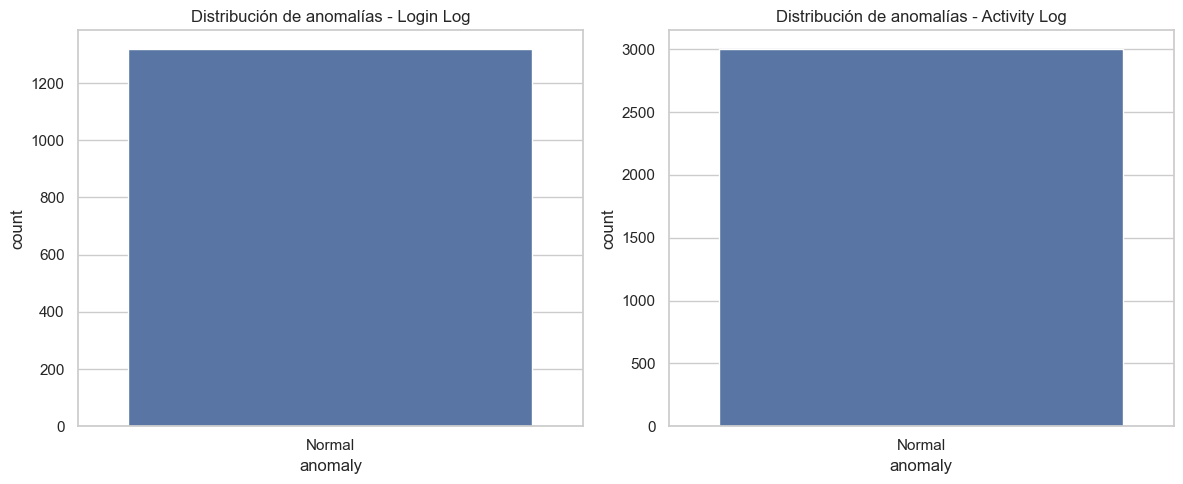

In [330]:
# Representamos visualmente cuántos casos normales y anómalos
# hay en Login Log y Activity Log.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras para anomalías en login.
sns.countplot(data=login_df, x="anomaly", ax=axes[0])
axes[0].set_title("Distribución de anomalías - Login Log")
axes[0].set_xticklabels(["Normal", "Anómalo"])

# Gráfico de barras para anomalías en actividad.
sns.countplot(data=activity_df, x="anomaly", ax=axes[1])
axes[1].set_title("Distribución de anomalías - Activity Log")
axes[1].set_xticklabels(["Normal", "Anómalo"])

plt.tight_layout()
plt.show()

Registros por usuario en Login Log


user_name
Matteo Nicolosi    440
Diego Scardino     439
Emilio Sardo       439
Name: count, dtype: int64

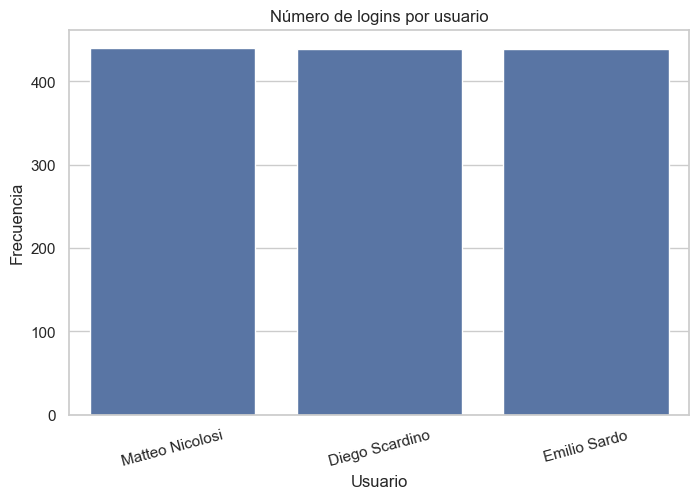

In [331]:
# Analizamos cuántos registros de login tiene cada usuario.
# Esto permite comprobar si todos los usuarios tienen
# suficiente representación en el dataset.
print("Registros por usuario en Login Log")
display(login_df["user_name"].value_counts())

# Visualización gráfica del número de logins por usuario.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="user_name")
plt.title("Número de logins por usuario")
plt.xlabel("Usuario")
plt.ylabel("Frecuencia")
plt.xticks(rotation=15)
plt.show()

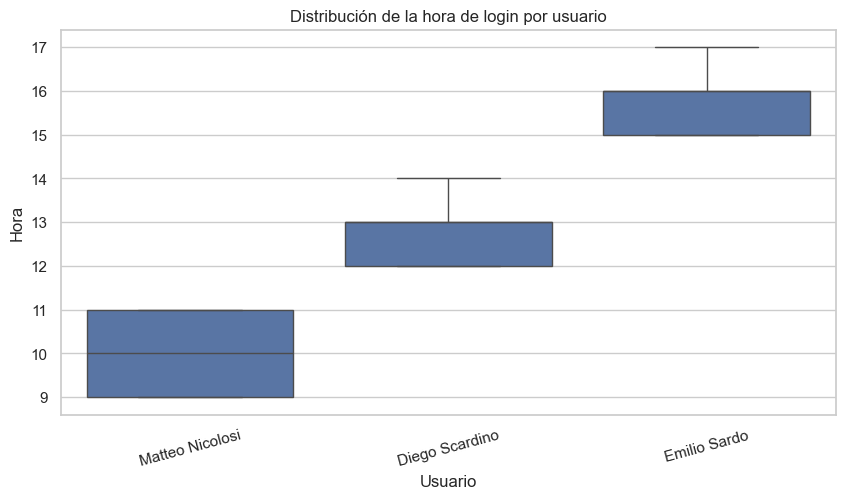

In [332]:
# El boxplot nos permite ver la dispersión de la hora de login
# para cada usuario y detectar visualmente posibles valores atípicos.
plt.figure(figsize=(10, 5))
sns.boxplot(data=login_df, x="user_name", y="hour")
plt.title("Distribución de la hora de login por usuario")
plt.xlabel("Usuario")
plt.ylabel("Hora")
plt.xticks(rotation=15)
plt.show()

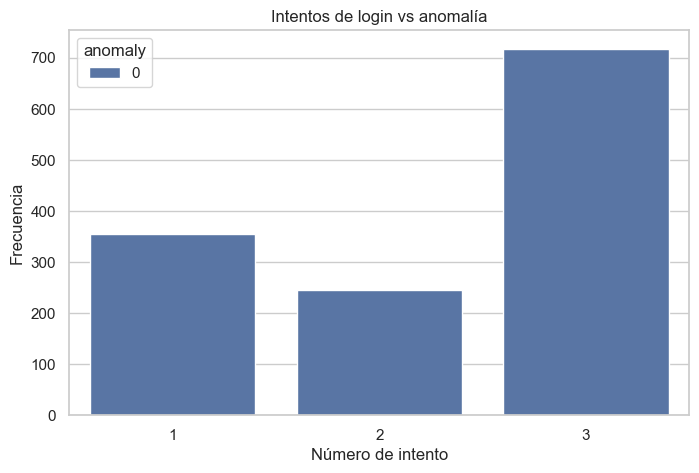

In [333]:
# Observamos cuántos logins se realizan al primer intento,
# segundo intento, etc., y si existe relación con la anomalía.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="attempt", hue="anomaly")
plt.title("Intentos de login vs anomalía")
plt.xlabel("Número de intento")
plt.ylabel("Frecuencia")
plt.show()

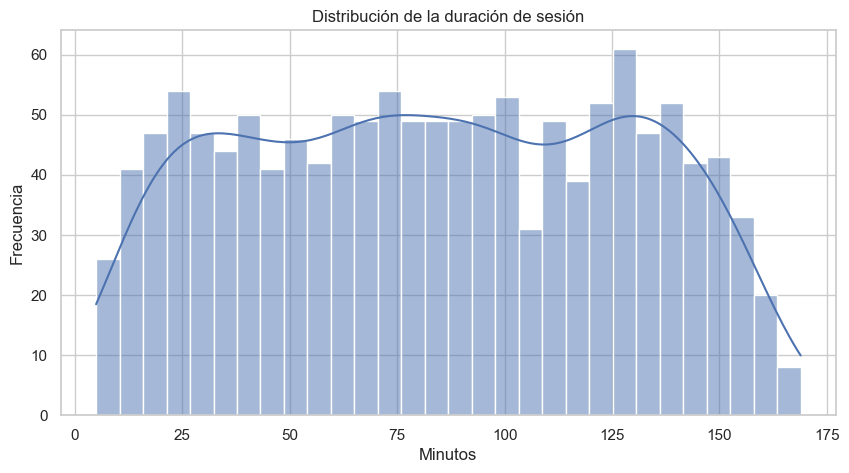

In [334]:
# Histograma de la duración de las sesiones de login.
# Se añade también una curva KDE para visualizar mejor la densidad.
plt.figure(figsize=(10, 5))
sns.histplot(login_df["session_duration_min"].dropna(), bins=30, kde=True)
plt.title("Distribución de la duración de sesión")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()

Acciones por usuario


user_name        action_name
Diego Scardino   Copy           341
                 Share          313
                 Visualize      302
                 Edit            14
                 Delete           1
Emilio Sardo     Share          340
                 Copy           340
                 Visualize      339
                 Edit             6
Matteo Nicolosi  Share          347
                 Copy           330
                 Visualize      311
                 Edit            16
Name: count, dtype: int64

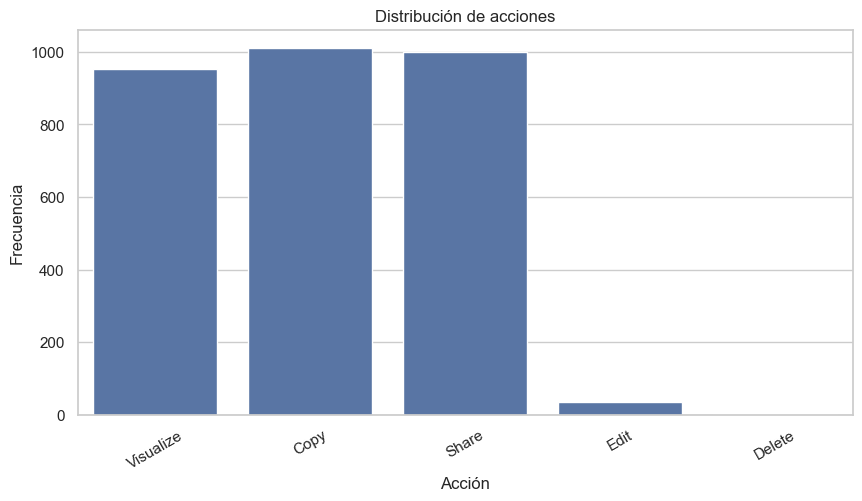

In [335]:
# Mostramos un resumen de cuántas veces realiza cada usuario
# cada tipo de acción.
print("Acciones por usuario")
display(activity_df.groupby("user_name")["action_name"].value_counts())

# Gráfico de la distribución global de acciones.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="action_name")
plt.title("Distribución de acciones")
plt.xlabel("Acción")
plt.ylabel("Frecuencia")
plt.xticks(rotation=30)
plt.show()

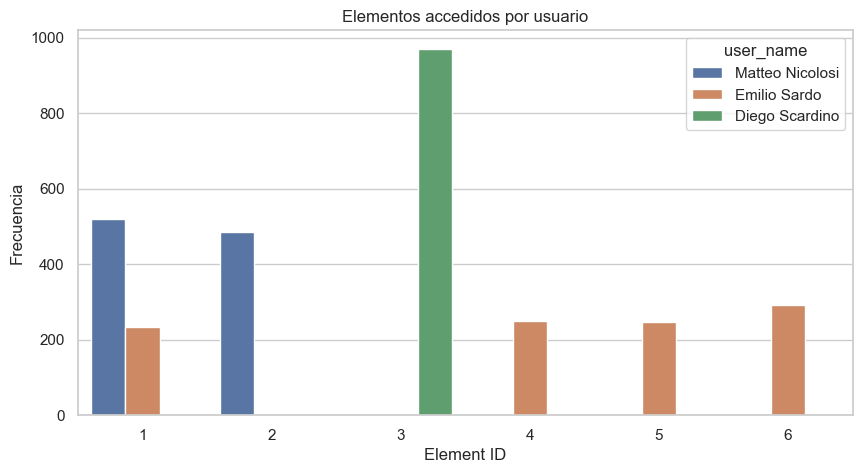

In [336]:
# Este gráfico permite ver qué element_id utiliza cada usuario.
# Es útil para detectar visualmente accesos fuera del conjunto esperado.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="element_id", hue="user_name")
plt.title("Elementos accedidos por usuario")
plt.xlabel("Element ID")
plt.ylabel("Frecuencia")
plt.show()

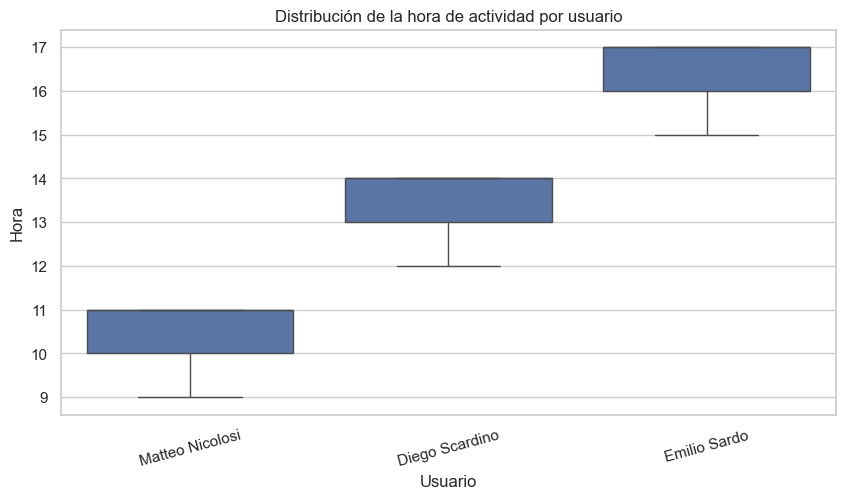

In [337]:
# Al igual que en login, usamos un boxplot para ver
# la distribución horaria de las actividades por usuario.
plt.figure(figsize=(10, 5))
sns.boxplot(data=activity_df, x="user_name", y="hour")
plt.title("Distribución de la hora de actividad por usuario")
plt.xlabel("Usuario")
plt.ylabel("Hora")
plt.xticks(rotation=15)
plt.show()

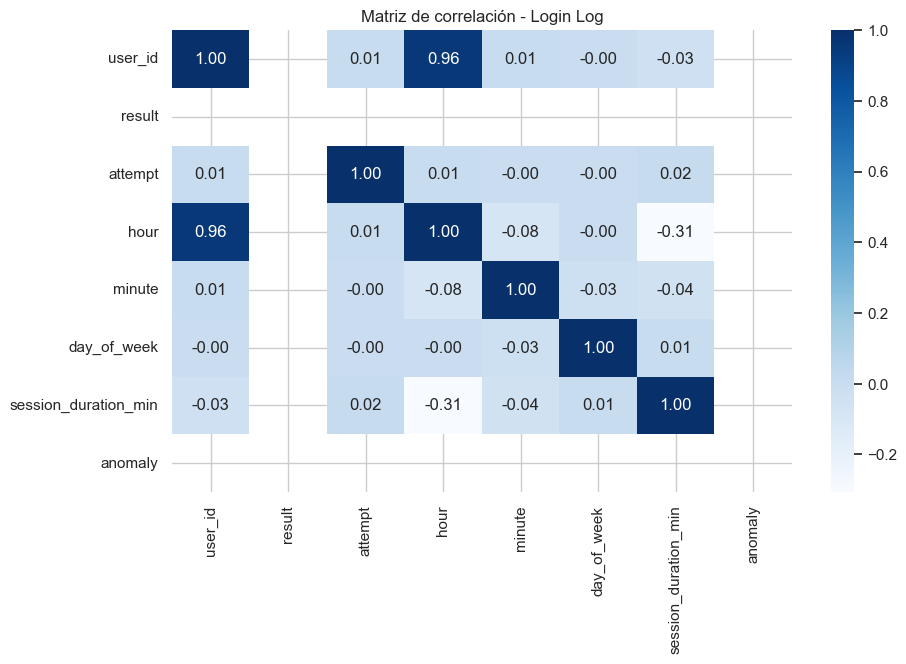

In [338]:
# Seleccionamos las variables numéricas más relevantes del dataset de login.
login_corr_cols = ["user_id", "result", "attempt", "hour", "minute", "day_of_week", "session_duration_min", "anomaly"]

# Heatmap de correlación.
# No implica causalidad, pero sí ayuda a explorar relaciones.
plt.figure(figsize=(10, 6))
sns.heatmap(login_df[login_corr_cols].corr(numeric_only=True), annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación - Login Log")
plt.show()

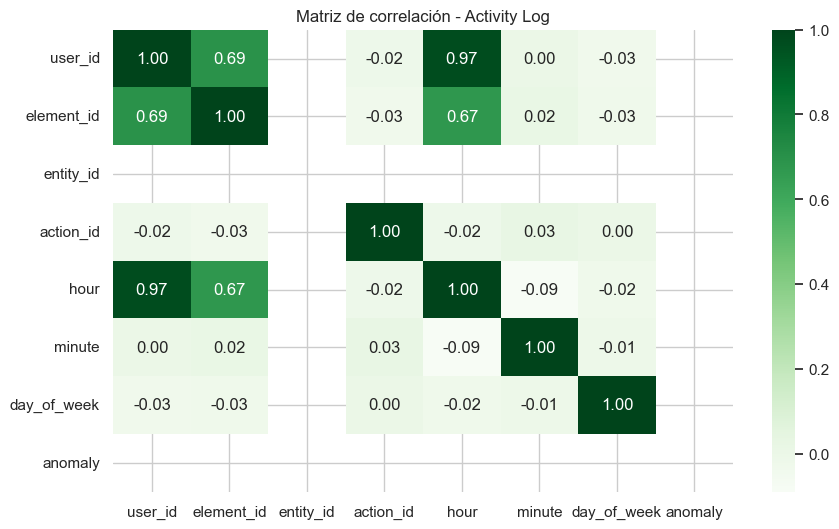

In [339]:
# Variables numéricas del dataset de actividad.
activity_corr_cols = ["user_id", "element_id", "entity_id", "action_id", "hour", "minute", "day_of_week", "anomaly"]

# Calculamos y representamos la matriz de correlación.
plt.figure(figsize=(10, 6))
sns.heatmap(activity_df[activity_corr_cols].corr(numeric_only=True), annot=True, cmap="Greens", fmt=".2f")
plt.title("Matriz de correlación - Activity Log")
plt.show()

In [340]:
# =========================
# PREPARACIÓN MODELO LOGIN
# =========================

login_model_df = login_df_model.copy()

login_model_df["result"] = login_model_df["result"].astype(int)

features_login = ["user_id", "result", "attempt", "hour", "minute", "day_of_week", "session_duration_min"]
target_login = "anomaly"

X_login = login_model_df[features_login].copy()
y_login = login_model_df[target_login].copy()

X_login["session_duration_min"] = X_login["session_duration_min"].fillna(0)

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_login, y_login, test_size=0.2, random_state=42, stratify=y_login
)

print("Train Login:", Xl_train.shape)
print("Test Login:", Xl_test.shape)

print("\nDistribución en train:")
print(yl_train.value_counts())

print("\nDistribución en test:")
print(yl_test.value_counts())

Train Login: (1054, 7)
Test Login: (264, 7)

Distribución en train:
anomaly
0    896
1    158
Name: count, dtype: int64

Distribución en test:
anomaly
0    224
1     40
Name: count, dtype: int64


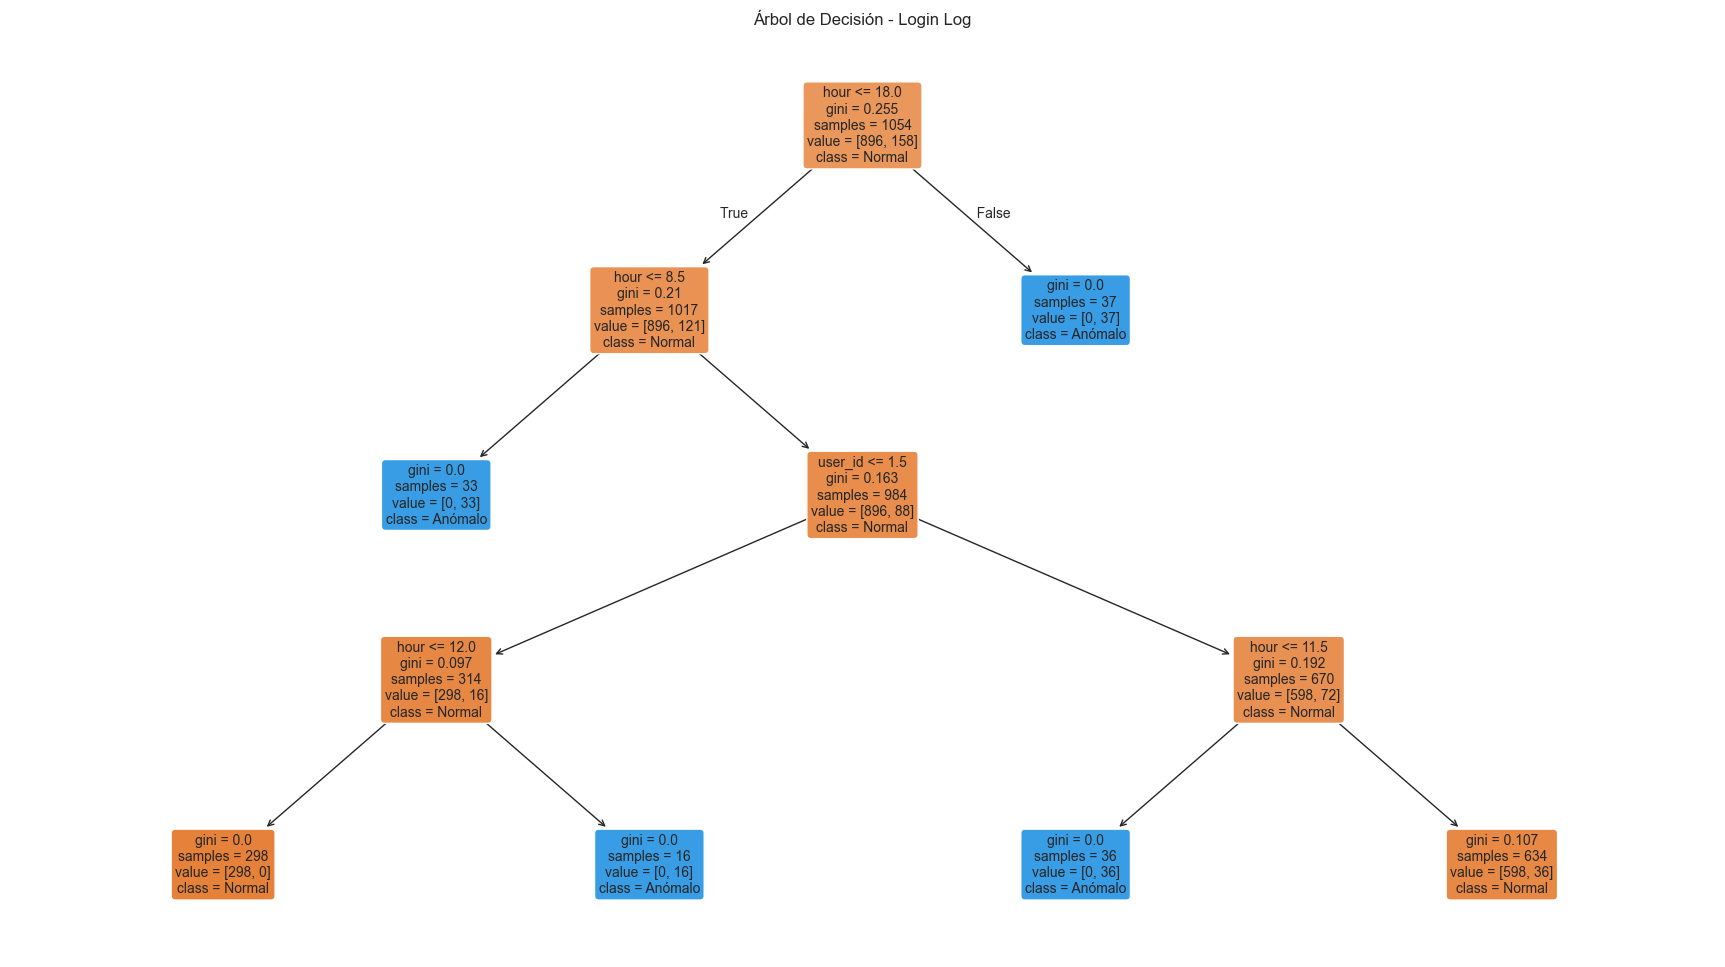

In [341]:
login_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

login_tree.fit(Xl_train, yl_train)

plt.figure(figsize=(22, 12))
plot_tree(
    login_tree,
    feature_names=features_login,
    class_names=["Normal", "Anómalo"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión - Login Log")
plt.show()

In [342]:
# Generamos predicciones sobre el conjunto de test,
# es decir, sobre datos no vistos durante el entrenamiento.
yl_pred = login_tree.predict(Xl_test)

# Accuracy global del modelo.
print("Accuracy Login:", accuracy_score(yl_test, yl_pred))

# El classification report ofrece precisión, recall y f1-score.
# Estas métricas son más informativas que la accuracy,
# especialmente si hay desbalance de clases.
print("\nClassification Report - Login")
print(classification_report(yl_test, yl_pred))

Accuracy Login: 0.9545454545454546

Classification Report - Login
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       224
           1       1.00      0.70      0.82        40

    accuracy                           0.95       264
   macro avg       0.97      0.85      0.90       264
weighted avg       0.96      0.95      0.95       264



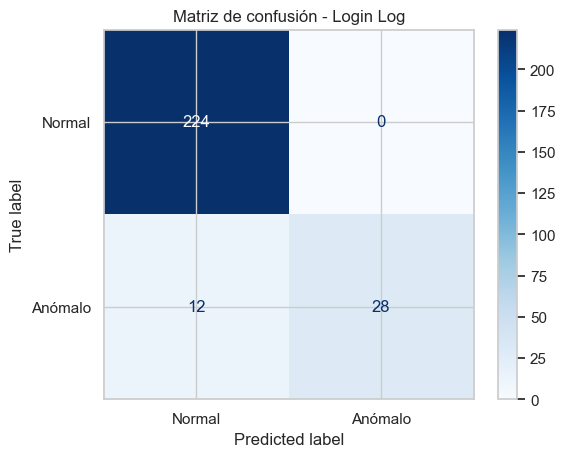

In [343]:
# La matriz de confusión muestra:
# - verdaderos normales
# - falsos positivos
# - falsos negativos
# - verdaderos anómalos

cm_login = confusion_matrix(yl_test, yl_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_login,
    display_labels=["Normal", "Anómalo"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Login Log")
plt.show()

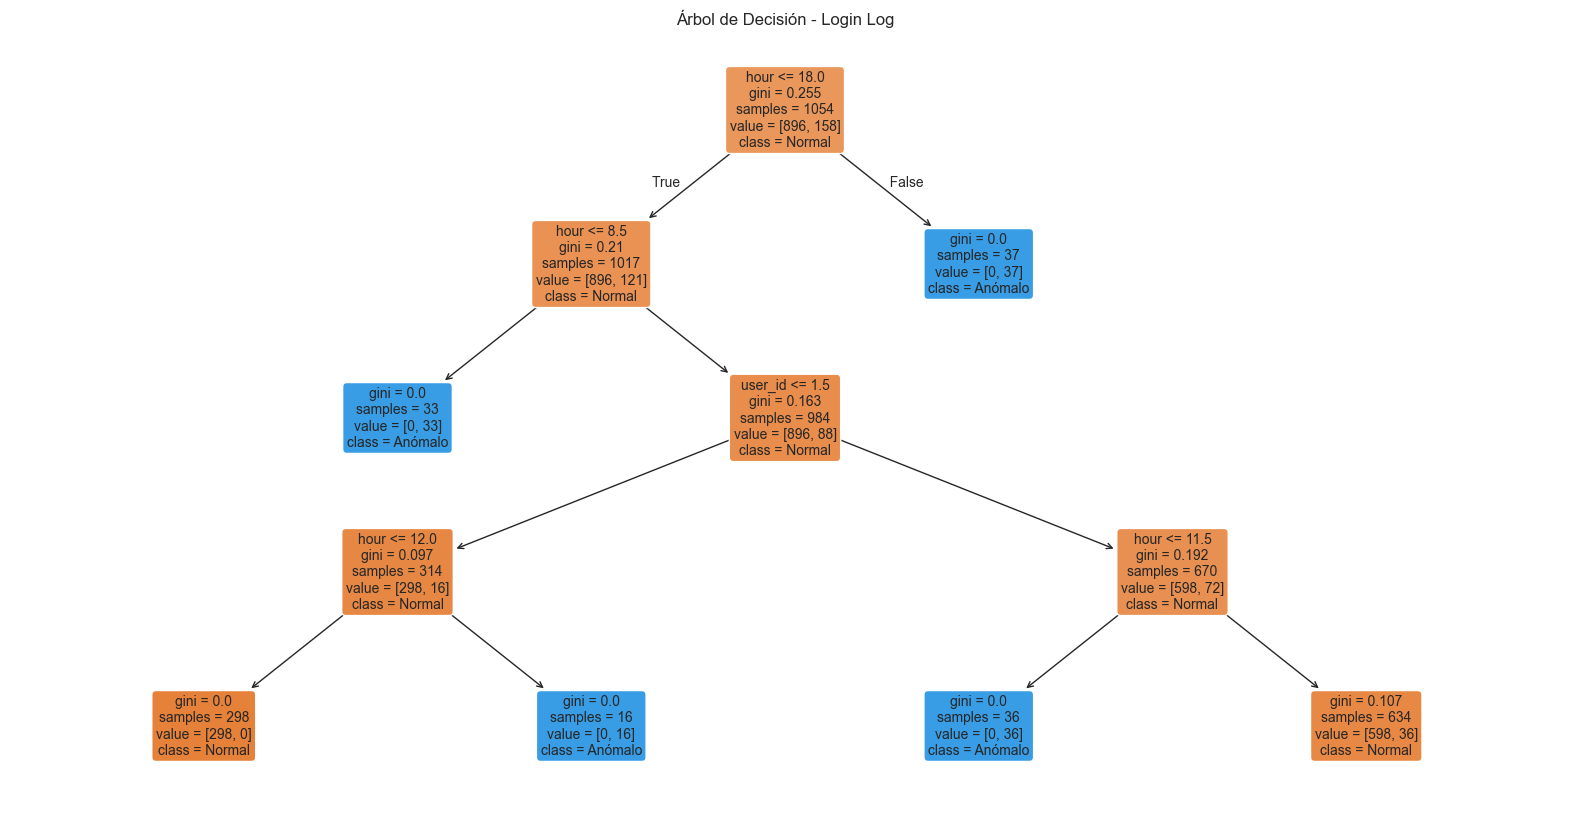

In [344]:
# Dibujamos el árbol completo para entender
# qué decisiones toma el modelo y en qué variables se apoya.
plt.figure(figsize=(20, 10))
plot_tree(
    login_tree,
    feature_names=features_login,
    class_names=["Normal", "Anómalo"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión - Login Log")
plt.show()

In [345]:
# export_text transforma el árbol a una representación textual.
# Esto facilita incluir reglas del modelo en documentación o informes.
rules_login = export_text(login_tree, feature_names=features_login)
print(rules_login)

|--- hour <= 18.00
|   |--- hour <= 8.50
|   |   |--- class: 1
|   |--- hour >  8.50
|   |   |--- user_id <= 1.50
|   |   |   |--- hour <= 12.00
|   |   |   |   |--- class: 0
|   |   |   |--- hour >  12.00
|   |   |   |   |--- class: 1
|   |   |--- user_id >  1.50
|   |   |   |--- hour <= 11.50
|   |   |   |   |--- class: 1
|   |   |   |--- hour >  11.50
|   |   |   |   |--- class: 0
|--- hour >  18.00
|   |--- class: 1



In [346]:
# =========================
# RECREAR LA VARIABLE OBJETIVO anomaly
# =========================

# Recalculamos anomaly sobre la copia modificada
activity_df_model["anomaly"] = activity_df_model.apply(activity_is_anomalous_v2, axis=1)

# Volvemos a crear el dataset final de modelado
activity_model_df = activity_df_model.copy()

# Rehacemos las variables derivadas por si acaso
activity_model_df["hour_decimal"] = (
    activity_model_df["hour"] + activity_model_df["minute"] / 60
)

activity_model_df["is_allowed_element"] = activity_model_df.apply(
    lambda row: 1 if row["element_id"] in allowed_elements.get(row["user_id"], []) else 0,
    axis=1
)

def is_allowed_user_hour(row):
    user_id = row["user_id"]
    hour = row["hour"]
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        return 1 if start_hour <= hour < end_hour else 0
    return 0

activity_model_df["is_allowed_user_hour"] = activity_model_df.apply(
    is_allowed_user_hour,
    axis=1
)

activity_model_df["is_weekday"] = activity_model_df["day_of_week"].between(0, 4).astype(int)

print(activity_model_df.columns.tolist())
print("\nDistribución de anomaly:")
print(activity_model_df["anomaly"].value_counts())

['activity_log_id', 'user_id', 'element_id', 'entity_id', 'action_id', 'logged_at', 'user_name', 'action_name', 'hour', 'minute', 'day_of_week', 'date', 'is_weekday', 'is_working_hours', 'anomaly', 'hour_decimal', 'is_allowed_element', 'is_allowed_user_hour']

Distribución de anomaly:
anomaly
0    2515
1     485
Name: count, dtype: int64


In [347]:
# =========================
# PREPARACIÓN MODELO ACTIVITY
# =========================

features_activity = [
    "user_id",
    "element_id",
    "entity_id",
    "action_id",
    "hour",
    "minute",
    "day_of_week",
    "hour_decimal",
    "is_allowed_element",
    "is_allowed_user_hour",
    "is_weekday"
]

target_activity = "anomaly"

X_activity = activity_model_df[features_activity].copy()
y_activity = activity_model_df[target_activity].copy()

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_activity,
    y_activity,
    test_size=0.2,
    random_state=42,
    stratify=y_activity
)

print("Train Activity:", Xa_train.shape)
print("Test Activity:", Xa_test.shape)

print("\nDistribución en train:")
print(ya_train.value_counts())

print("\nDistribución en test:")
print(ya_test.value_counts())

Train Activity: (2400, 11)
Test Activity: (600, 11)

Distribución en train:
anomaly
0    2012
1     388
Name: count, dtype: int64

Distribución en test:
anomaly
0    503
1     97
Name: count, dtype: int64


In [348]:
# =========================
# MODELO ACTIVITY
# =========================

activity_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

activity_tree.fit(Xa_train, ya_train)

print("Modelo de Activity entrenado correctamente.")
print("Accuracy train:", activity_tree.score(Xa_train, ya_train))
print("Accuracy test:", activity_tree.score(Xa_test, ya_test))

Modelo de Activity entrenado correctamente.
Accuracy train: 1.0
Accuracy test: 1.0


In [349]:
# Predicción sobre test
ya_pred = activity_tree.predict(Xa_test)

print("Accuracy Activity:", accuracy_score(ya_test, ya_pred))
print("\nClassification Report - Activity")
print(
    classification_report(
        ya_test,
        ya_pred,
        labels=[0, 1],
        target_names=["Normal", "Anómalo"],
        zero_division=0
    )
)

Accuracy Activity: 1.0

Classification Report - Activity
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       503
     Anómalo       1.00      1.00      1.00        97

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



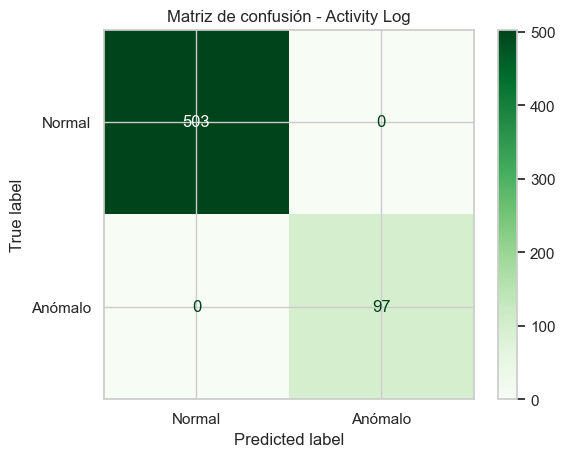

In [350]:
cm_activity = confusion_matrix(ya_test, ya_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_activity,
    display_labels=["Normal", "Anómalo"]
)

disp.plot(cmap="Greens")
plt.title("Matriz de confusión - Activity Log")
plt.show()

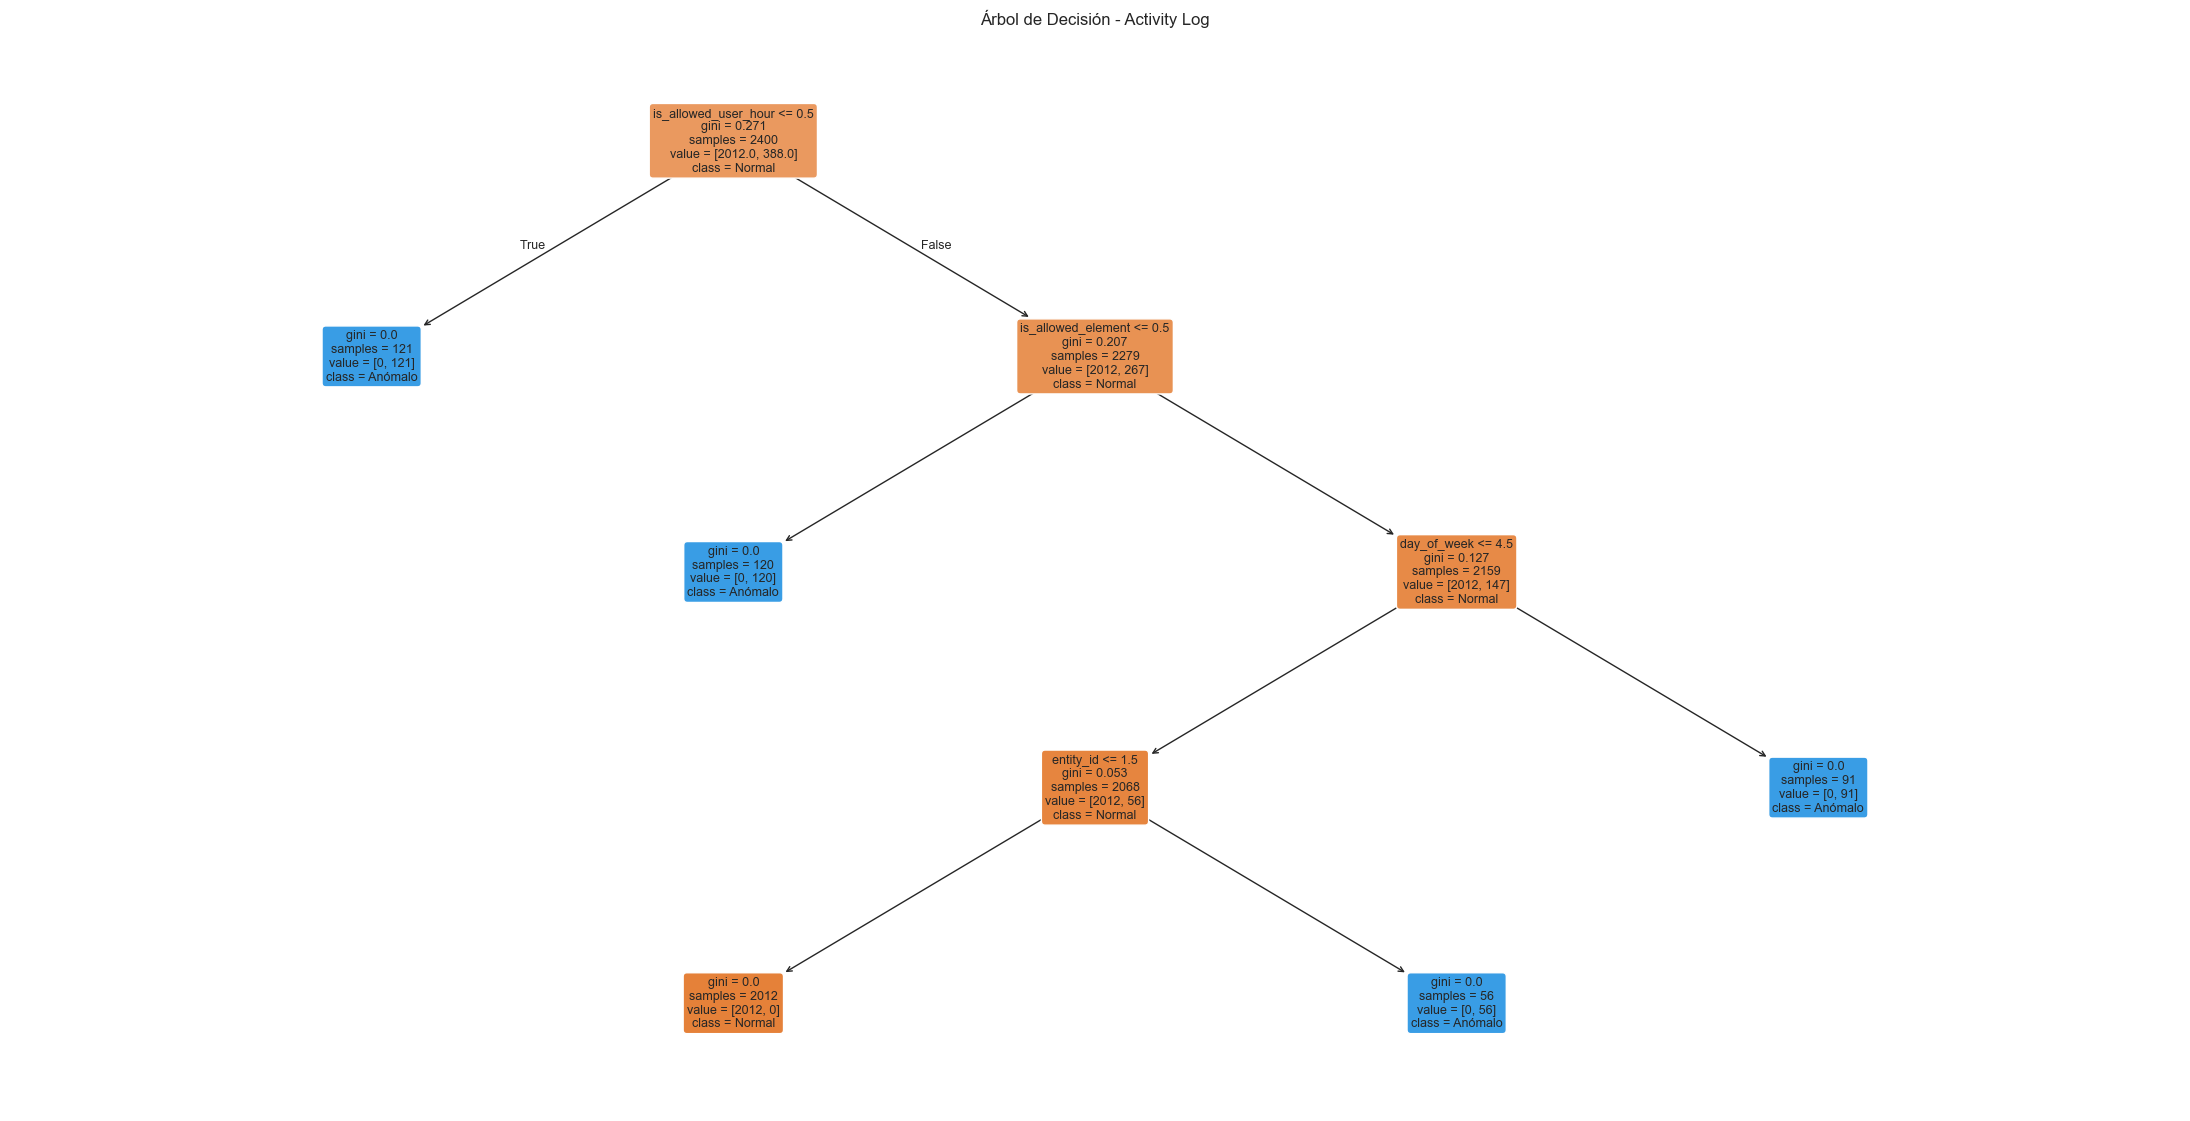

In [351]:
plt.figure(figsize=(28, 14))
plot_tree(
    activity_tree,
    feature_names=features_activity,
    class_names=["Normal", "Anómalo"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de Decisión - Activity Log")
plt.show()

In [352]:
# Convertimos el árbol de actividad en una representación textual.
# Esto hace más fácil revisar y documentar las reglas de decisión.
rules_activity = export_text(activity_tree, feature_names=features_activity)
print(rules_activity)

|--- is_allowed_user_hour <= 0.50
|   |--- class: 1
|--- is_allowed_user_hour >  0.50
|   |--- is_allowed_element <= 0.50
|   |   |--- class: 1
|   |--- is_allowed_element >  0.50
|   |   |--- day_of_week <= 4.50
|   |   |   |--- entity_id <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- entity_id >  1.50
|   |   |   |   |--- class: 1
|   |   |--- day_of_week >  4.50
|   |   |   |--- class: 1



In [353]:
# =========================
# IMPORTANCIA DE VARIABLES
# =========================

importance_df = pd.DataFrame({
    "feature": features_activity,
    "importance": activity_tree.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
8,is_allowed_element,0.303523
9,is_allowed_user_hour,0.275320
6,day_of_week,0.253656
2,entity_id,0.167501
0,user_id,0.000000
1,element_id,0.000000
3,action_id,0.000000
4,hour,0.000000
5,minute,0.000000
7,hour_decimal,0.000000


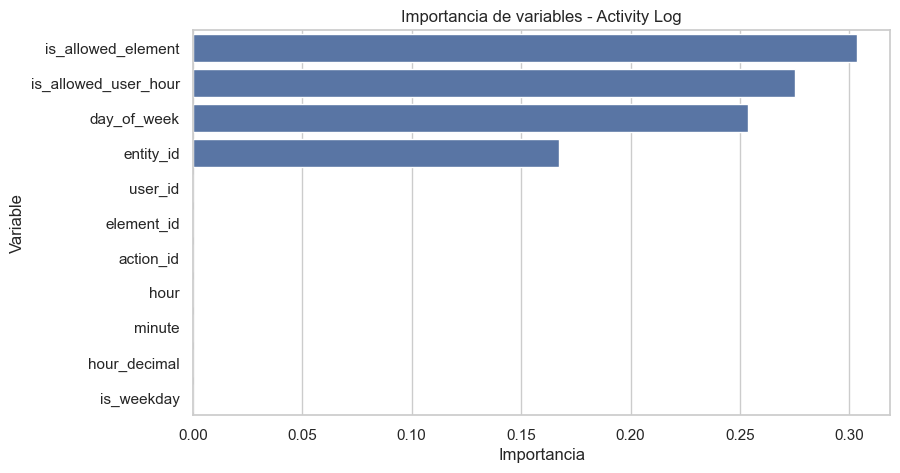

In [354]:
plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Importancia de variables - Activity Log")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [355]:
# Aplicamos ambos modelos sobre todos los registros para comparar
# la etiqueta real generada por reglas con la predicción del árbol.
login_df["predicted_anomaly"] = login_tree.predict(X_login)
activity_df["predicted_anomaly"] = activity_tree.predict(X_activity)

# Mostramos una comparación entre la anomalía real y la predicha
# en el dataset de login.
print("LOGIN - comparación real vs predicción")
display(login_df[["login_log_id", "user_id", "user_name", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

# Hacemos lo mismo con el dataset de actividad.
print("\nACTIVITY - comparación real vs predicción")
display(activity_df[["activity_log_id", "user_id", "user_name", "element_id", "action_id", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

LOGIN - comparación real vs predicción


,login_log_id,user_id,user_name,logged_at,anomaly,predicted_anomaly
0,3,1,Matteo Nicolosi,2026-01-01 09:06:55.942,0,0
1,4,2,Diego Scardino,2026-01-01 12:23:22.204,0,0
2,6,3,Emilio Sardo,2026-01-01 17:40:17.890,0,0
3,9,1,Matteo Nicolosi,2026-01-02 10:10:32.177,0,0
4,10,2,Diego Scardino,2026-01-02 12:47:29.386,0,0
5,12,3,Emilio Sardo,2026-01-02 16:12:38.083,0,0
6,13,1,Matteo Nicolosi,2026-01-05 09:20:03.990,0,0
7,16,2,Diego Scardino,2026-01-05 13:49:11.388,0,0
8,17,3,Emilio Sardo,2026-01-05 16:22:10.634,0,0
9,18,1,Matteo Nicolosi,2026-01-06 09:20:18.448,0,0



ACTIVITY - comparación real vs predicción


,activity_log_id,user_id,user_name,element_id,action_id,logged_at,anomaly,predicted_anomaly
0,1,1,Matteo Nicolosi,2,1000000,2026-01-01 10:31:04.217,0,1
1,2,2,Diego Scardino,3,1000004,2026-01-01 14:37:47.860,0,0
2,3,3,Emilio Sardo,6,1000005,2026-01-01 17:44:36.455,0,0
3,4,1,Matteo Nicolosi,1,1000000,2026-01-02 10:14:36.855,0,0
4,5,1,Matteo Nicolosi,2,1000000,2026-01-02 10:15:31.904,0,0
5,6,1,Matteo Nicolosi,2,1000004,2026-01-02 10:34:10.221,0,0
6,7,1,Matteo Nicolosi,1,1000005,2026-01-02 10:45:38.782,0,0
7,8,1,Matteo Nicolosi,1,1000004,2026-01-02 10:50:27.144,0,0
8,9,1,Matteo Nicolosi,2,1000005,2026-01-02 11:00:25.523,0,0
9,10,1,Matteo Nicolosi,1,1000005,2026-01-02 11:17:42.260,0,0


In [356]:
# Filtramos únicamente los registros que el modelo clasifica como anómalos.
login_anomalies = login_df[login_df["predicted_anomaly"] == 1].copy()

print("Casos anómalos detectados en Login:")
display(
    login_anomalies[
        ["login_log_id", "user_id", "user_name", "result", "attempt", "logged_at", "logout_at", "hour"]
    ].sort_values("logged_at")
)

Casos anómalos detectados en Login:


,login_log_id,user_id,user_name,result,attempt,logged_at,logout_at,hour
192,417,1,Matteo Nicolosi,True,3,2026-01-01 10:42:02.987,2026-01-01 11:40:37.554,10
578,1267,3,Emilio Sardo,True,2,2026-01-01 15:53:44.327,2026-01-01 17:43:41.604,15
770,1731,3,Emilio Sardo,True,3,2026-01-01 16:23:54.574,2026-01-01 17:43:11.107,16
962,2171,3,Emilio Sardo,True,2,2026-01-01 16:37:50.204,2026-01-01 17:48:11.993,16
771,1734,1,Matteo Nicolosi,True,3,2026-01-02 11:20:43.708,2026-01-02 11:41:05.022,11
...,...,...,...,...,...,...,...,...
377,836,3,Emilio Sardo,True,3,2026-03-27 16:55:02.600,2026-03-27 17:39:08.676,16
762,1713,1,Matteo Nicolosi,True,2,2026-03-30 11:14:41.957,2026-03-30 11:53:22.652,11
1148,2594,3,Emilio Sardo,True,3,2026-03-30 15:59:40.586,2026-03-30 17:40:49.559,15
572,1255,3,Emilio Sardo,True,3,2026-03-30 16:11:32.531,2026-03-30 17:38:20.007,16


In [357]:
# Filtramos las actividades marcadas como anómalas por el modelo.
activity_anomalies = activity_df[activity_df["predicted_anomaly"] == 1].copy()

print("Casos anómalos detectados en Activity:")
display(
    activity_anomalies[
        ["activity_log_id", "user_id", "user_name", "element_id", "entity_id", "action_id", "action_name", "logged_at", "hour"]
    ].sort_values("logged_at")
)

Casos anómalos detectados en Activity:


,activity_log_id,user_id,user_name,element_id,entity_id,action_id,action_name,logged_at,hour
0,1,1,Matteo Nicolosi,2,1,1000000,Visualize,2026-01-01 10:31:04.217,10
1360,1361,1,Matteo Nicolosi,2,1,1000005,Share,2026-01-01 11:38:22.967,11
929,930,1,Matteo Nicolosi,1,1,1000005,Share,2026-01-01 11:39:26.805,11
2236,2237,1,Matteo Nicolosi,2,1,1000004,Copy,2026-01-01 11:49:25.162,11
930,931,2,Diego Scardino,3,1,1000004,Copy,2026-01-01 13:13:07.401,13
...,...,...,...,...,...,...,...,...,...
430,431,3,Emilio Sardo,4,1,1000000,Visualize,2026-03-31 17:06:39.634,17
1359,1360,3,Emilio Sardo,1,1,1000004,Copy,2026-03-31 17:16:30.554,17
2230,2231,3,Emilio Sardo,6,1,1000000,Visualize,2026-03-31 17:33:27.027,17
926,927,3,Emilio Sardo,4,1,1000000,Visualize,2026-03-31 17:42:58.490,17


In [358]:
# Definimos una función que permite probar manualmente
# nuevos casos de login sin tener que rehacer todo el pipeline.
def predict_login_anomaly(user_id, result, attempt, logged_at, logout_at):
    # Convertimos las fechas introducidas a datetime.
    logged_at = pd.to_datetime(logged_at)
    logout_at = pd.to_datetime(logout_at)

    # Construimos un DataFrame con la misma estructura
    # de variables que espera el modelo.
    row = pd.DataFrame([{
        "user_id": user_id,
        "result": int(result),
        "attempt": attempt,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek,
        "session_duration_min": (logout_at - logged_at).total_seconds() / 60
    }])

    # Obtenemos la predicción y las probabilidades.
    pred = login_tree.predict(row)[0]
    prob = login_tree.predict_proba(row)[0]

    # Mostramos resultado.
    print("Predicción:", "ANÓMALO" if pred == 1 else "NORMAL")
    print("Probabilidades [Normal, Anómalo]:", prob)

# Ejemplo de uso:
predict_login_anomaly(
    user_id=1,
    result=True,
    attempt=2,
    logged_at="2026-01-15 16:30:00",
    logout_at="2026-01-15 17:00:00"
)

Predicción: ANÓMALO
Probabilidades [Normal, Anómalo]: [0. 1.]


In [359]:
def predict_activity_anomaly(user_id, element_id, entity_id, action_id, logged_at):
    logged_at = pd.to_datetime(logged_at)

    hour = logged_at.hour
    minute = logged_at.minute
    day_of_week = logged_at.dayofweek
    hour_decimal = hour + minute / 60

    is_allowed_element = 1 if element_id in allowed_elements.get(user_id, []) else 0

    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        is_allowed_user_hour = 1 if start_hour <= hour < end_hour else 0
    else:
        is_allowed_user_hour = 0

    is_weekday = 1 if day_of_week in [0, 1, 2, 3, 4] else 0

    row = pd.DataFrame([{
        "user_id": user_id,
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": hour,
        "minute": minute,
        "day_of_week": day_of_week,
        "hour_decimal": hour_decimal,
        "is_allowed_element": is_allowed_element,
        "is_allowed_user_hour": is_allowed_user_hour,
        "is_weekday": is_weekday
    }])

    pred = activity_tree.predict(row)[0]
    prob = activity_tree.predict_proba(row)[0]

    print("Predicción:", "ANÓMALO" if pred == 1 else "NORMAL")
    print("Probabilidades [Normal, Anómalo]:", prob)

In [360]:
# Caso normal
predict_activity_anomaly(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000000,
    logged_at="2026-01-15 10:15:00"
)

# Caso anómalo por horario
predict_activity_anomaly(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000000,
    logged_at="2026-01-15 20:30:00"
)

# Caso anómalo por elemento no permitido
predict_activity_anomaly(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000004,
    logged_at="2026-01-15 13:00:00"
)

# Caso anómalo por entidad no válida
predict_activity_anomaly(
    user_id=3,
    element_id=6,
    entity_id=2,
    action_id=1000005,
    logged_at="2026-01-15 16:30:00"
)

Predicción: NORMAL
Probabilidades [Normal, Anómalo]: [1. 0.]
Predicción: ANÓMALO
Probabilidades [Normal, Anómalo]: [0. 1.]
Predicción: ANÓMALO
Probabilidades [Normal, Anómalo]: [0. 1.]
Predicción: ANÓMALO
Probabilidades [Normal, Anómalo]: [0. 1.]


"""
CONCLUSIONES
============

1. Se han cargado y analizado dos fuentes de datos:
   - Login Log
   - Activity Log

2. Se han transformado las fechas y generado variables temporales útiles para el análisis:
   - hora
   - minuto
   - día de la semana
   - duración de sesión

3. Se han implementado reglas de negocio para etiquetar registros anómalos:
   - Login fuera de la franja habitual del usuario
   - Login fuera de lunes a viernes
   - Actividad fuera del horario laboral
   - Actividad sobre elementos no autorizados
   - Actividad sobre entity distinta de password
   - Actividad con acciones no esperadas en el flujo estándar
   - Actividad fuera de la franja horaria habitual del usuario

4. Se han entrenado dos modelos de Árbol de Decisión:
   - Uno para Login Log
   - Uno para Activity Log

5. Los árboles de decisión permiten:
   - Explicar fácilmente la lógica de clasificación
   - Interpretar qué variables influyen más en la detección
   - Construir una PoC clara y defendible ante negocio

6. Este enfoque es adecuado para una primera PoC de detección de anomalías,
   ya que combina reglas de negocio con un modelo interpretable.

MEJORAS FUTURAS
===============
- Añadir más usuarios y más casuísticas reales.
- Incluir secuencias completas de comportamiento (login -> actividad -> logout).
- Introducir features agregadas por usuario y día.
- Probar Random Forest o XGBoost para mejorar robustez.
- Construir un sistema en tiempo real para bloquear acciones sospechosas.
"""

In [361]:
print(activity_df["anomaly"].value_counts())

print("\nAnomalías por action_id:")
print(pd.crosstab(activity_df["action_id"], activity_df["anomaly"]))

print("\nAnomalías por element_id:")
print(pd.crosstab(activity_df["element_id"], activity_df["anomaly"]))

print("\nAnomalías por user_id:")
print(pd.crosstab(activity_df["user_id"], activity_df["anomaly"]))

print("\nAnomalías por hour:")
print(activity_df.groupby("hour")["anomaly"].mean().sort_index())

anomaly
0    3000
Name: count, dtype: int64

Anomalías por action_id:
anomaly       0
action_id      
1000000     952
1000002      36
1000003       1
1000004    1011
1000005    1000

Anomalías por element_id:
anomaly       0
element_id     
1           754
2           485
3           971
4           250
5           247
6           293

Anomalías por user_id:
anomaly     0
user_id      
1        1004
2         971
3        1025

Anomalías por hour:
hour
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
Name: anomaly, dtype: float64


In [362]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(Xa_train, ya_train)

ya_pred_log = log_model.predict(Xa_test)

print("Accuracy Logistic Regression:", accuracy_score(ya_test, ya_pred_log))
print(classification_report(ya_test, ya_pred_log, labels=[0, 1], target_names=["Normal", "Anómalo"], zero_division=0))

Accuracy Logistic Regression: 1.0
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       503
     Anómalo       1.00      1.00      1.00        97

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

